## Análise de Risco de Crédito: Ingestão e Engenharia de Features

**Objetivo:** Consumir os dados originais do *German Credit Dataset* (UCI), realizar a análise exploratória inicial e aplicar o *One-Hot Encoding* nas variáveis categóricas preparando a base para modelagem.

Dados do site: https://archive.ics.uci.edu/dataset/144/statlog+german+credit+data 


In [ ]:
from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split
import pandas as pd

statlog_german_credit_data = fetch_ucirepo(id=144)

X = statlog_german_credit_data.data.features.copy()
y = statlog_german_credit_data.data.targets.copy()

if not isinstance(X, pd.DataFrame):
    X = pd.DataFrame(X)

if not isinstance(y, pd.DataFrame):
    y = pd.DataFrame(y)

# Padroniza o nome da coluna alvo para 'class'
target_name = y.columns[0]
y = y.rename(columns={target_name: 'class'})

# Monta o dataframe para EDA

df_eda = X.copy()
df_eda['class'] = y['class'].astype(int)
df_eda['class_label'] = df_eda['class']

# Identifica colunas numéricas e categóricas
colunas_numericas = [col for col in X.columns if pd.api.types.is_numeric_dtype(X[col])]
colunas_categoricas = [col for col in X.columns if col not in colunas_numericas]

# Split estratificado para treino, validação e teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y['class']
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.25, random_state=42, stratify=y_train['class']
)

print(statlog_german_credit_data.metadata)
print(statlog_german_credit_data.variables)
print('\nDistribuição da variável alvo:')
print(y['class'].value_counts().to_frame('quantidade'))
print(y['class'].value_counts(normalize=True).round(4).to_frame('percentual'))


## Análise de Balanceamento e Outliers

Nesta etapa, entenderemos a distribuição individual dos dados.Primeiro, foi verificada a proporção da variável alvo para identificar se o dataset sofre de desbalanceamento severo (algo comum em cenários de fraude e crédito). Em seguida, utilizamos boxplots nas variáveis numéricas para mapear possíveis outliers que possam distorcer o aprendizado do algoritmo.

> **Nota sobre as variáveis categóricas:** Para as outras 13 variáveis qualitativas (como Histórico de Crédito ou Status da Conta), eventuais desbalanceamentos e "categorias raras" serão avaliados visualmente através da análise de frequência (gráficos de barras) na etapa bivariada.

> **Nota de Negócios:** Os *outliers* detectados nas variáveis contínuas (como altos valores de crédito, prazos longos ou idade avançada) representam perfis financeiros reais e não erros de sistema. Portanto, **eles não serão removidos da base**. Eliminar esses dados deixaria o modelo "cego" justamente para as operações mais sensíveis e de alto risco.


--- BALANCEAMENTO DA VARIÁVEL ALVO ---
             Quantidade  Percentual (%)
class_label                            
1                   700            70.0
2                   300            30.0


--- DETECÇÃO DE OUTLIERS (VARIÁVEIS NUMÉRICAS) ---


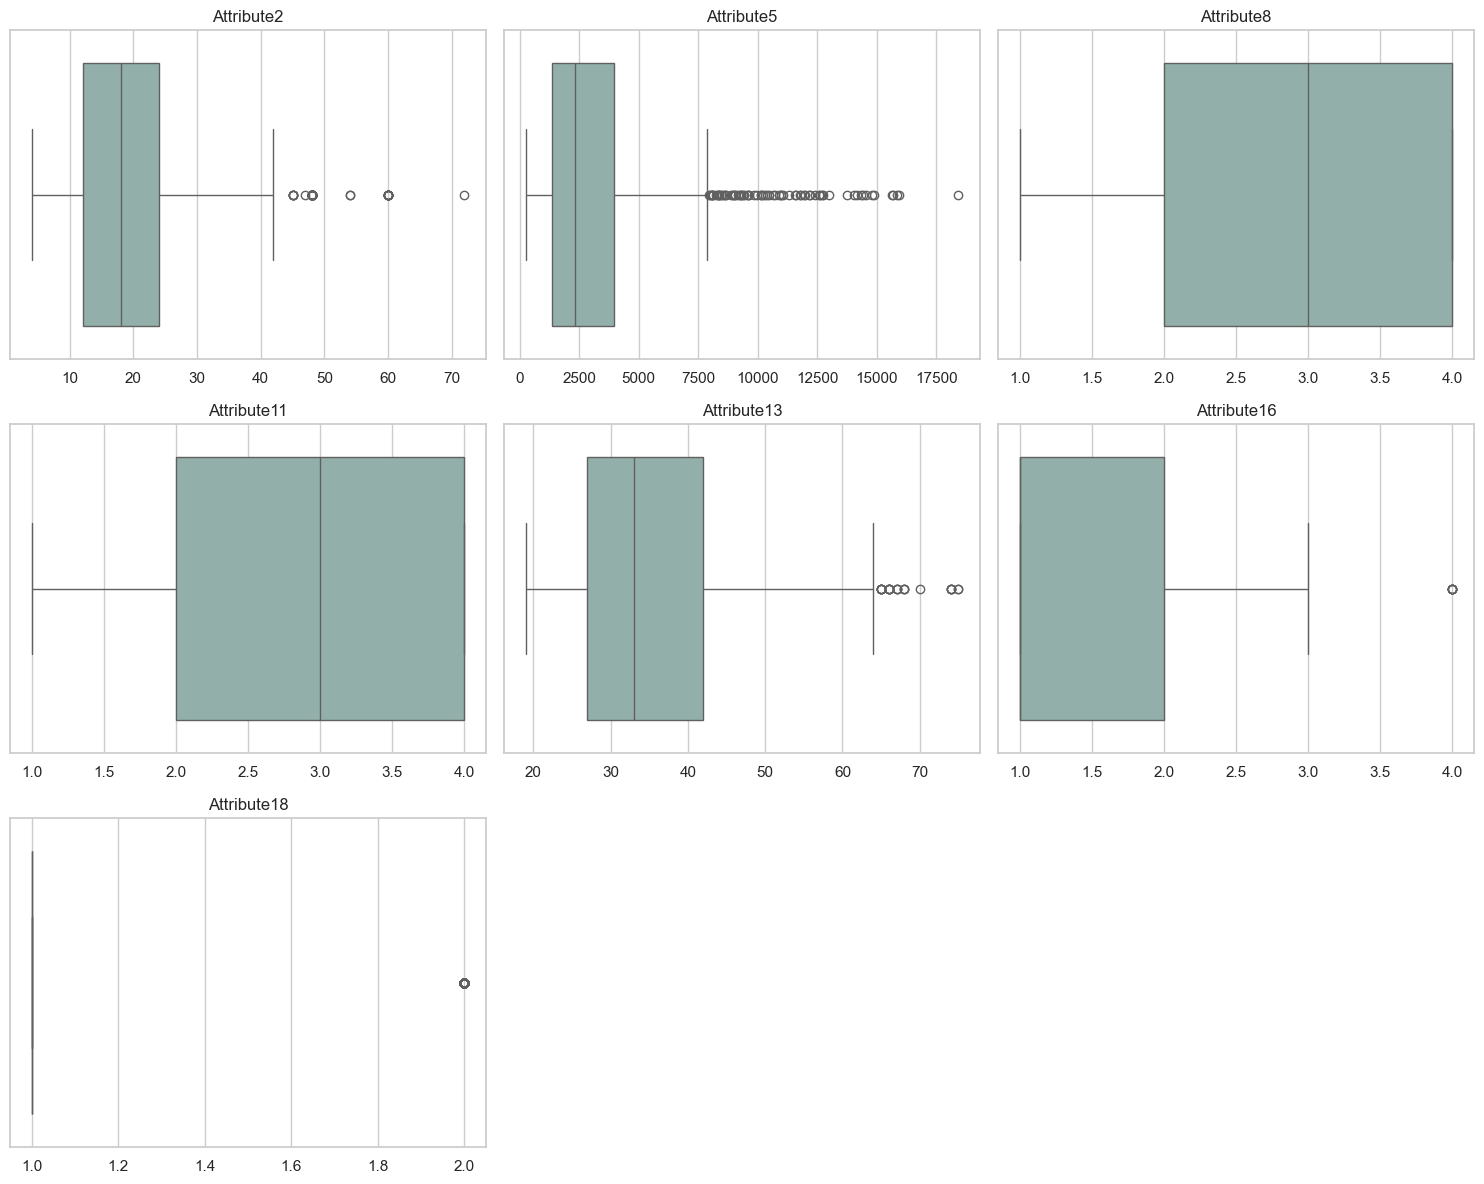

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

#Proporção da variável alvo
print("--- BALANCEAMENTO DA VARIÁVEL ALVO ---")
contagem = df_eda['class_label'].value_counts()
percentual = df_eda['class_label'].value_counts(normalize=True) * 100

resumo_alvo = pd.DataFrame({
    'Quantidade': contagem,
    'Percentual (%)': percentual.round(2)
})
print(resumo_alvo)
print("\n")

#Boxplots para detectar Outliers nas variáveis numéricas
print("--- DETECÇÃO DE OUTLIERS (VARIÁVEIS NUMÉRICAS) ---")

linhas_box = math.ceil(len(colunas_numericas) / 3)
plt.figure(figsize=(15, 4 * linhas_box))

for i, coluna in enumerate(colunas_numericas, 1):
    plt.subplot(linhas_box, 3, i)
    sns.boxplot(data=df_eda, x=coluna, color='#8DB4AD')
    plt.title(f'{coluna}', fontsize=12)
    plt.xlabel('')

plt.tight_layout()
plt.show()


## Análise Bivariada: O Perfil do Risco

Com a base validada e o desbalanceamento mapeado, o objetivo agora é cruzar as nossas variáveis com a variável alvo. O intuito é responder à principal pergunta de negócios: **Quais características diferenciam um bom pagador de um cliente de alto risco?**

Os gráficos abaixo exploram essas relações para extrairmos os *insights* que guiarão o algoritmo preditivo.


--- ANÁLISE BIVARIADA: VARIÁVEIS NUMÉRICAS vs ALVO ---


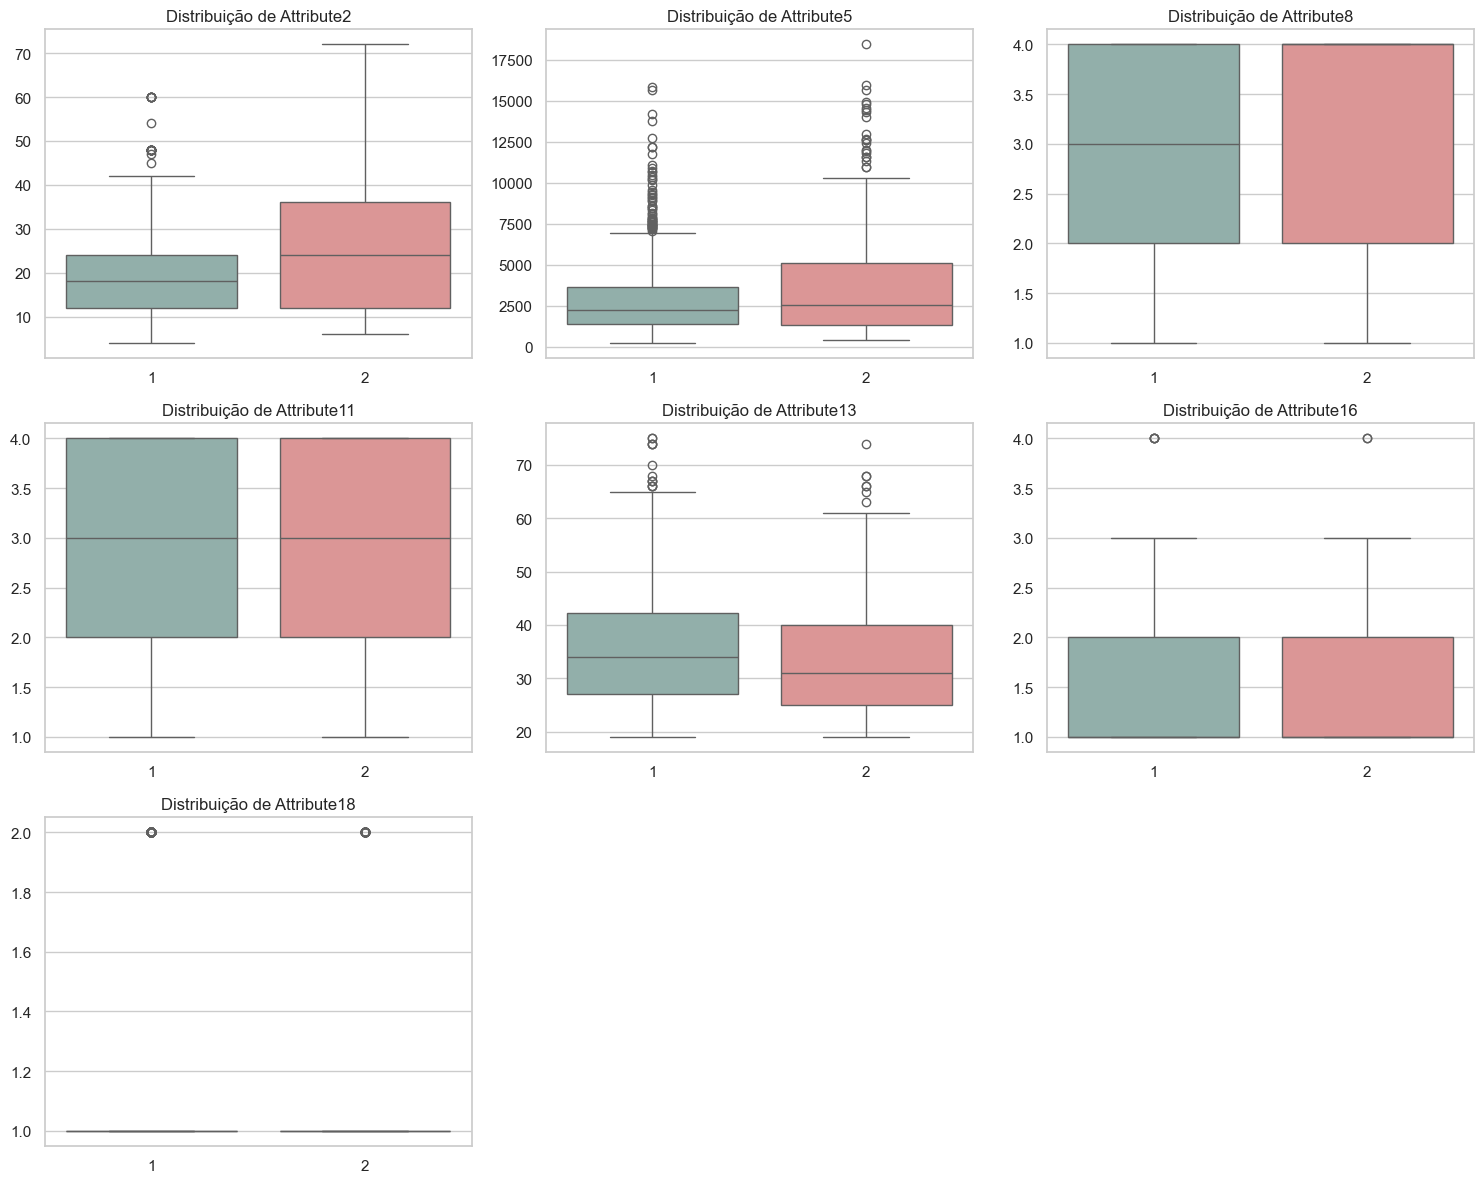


--- ANÁLISE BIVARIADA: VARIÁVEIS CATEGÓRICAS vs ALVO ---


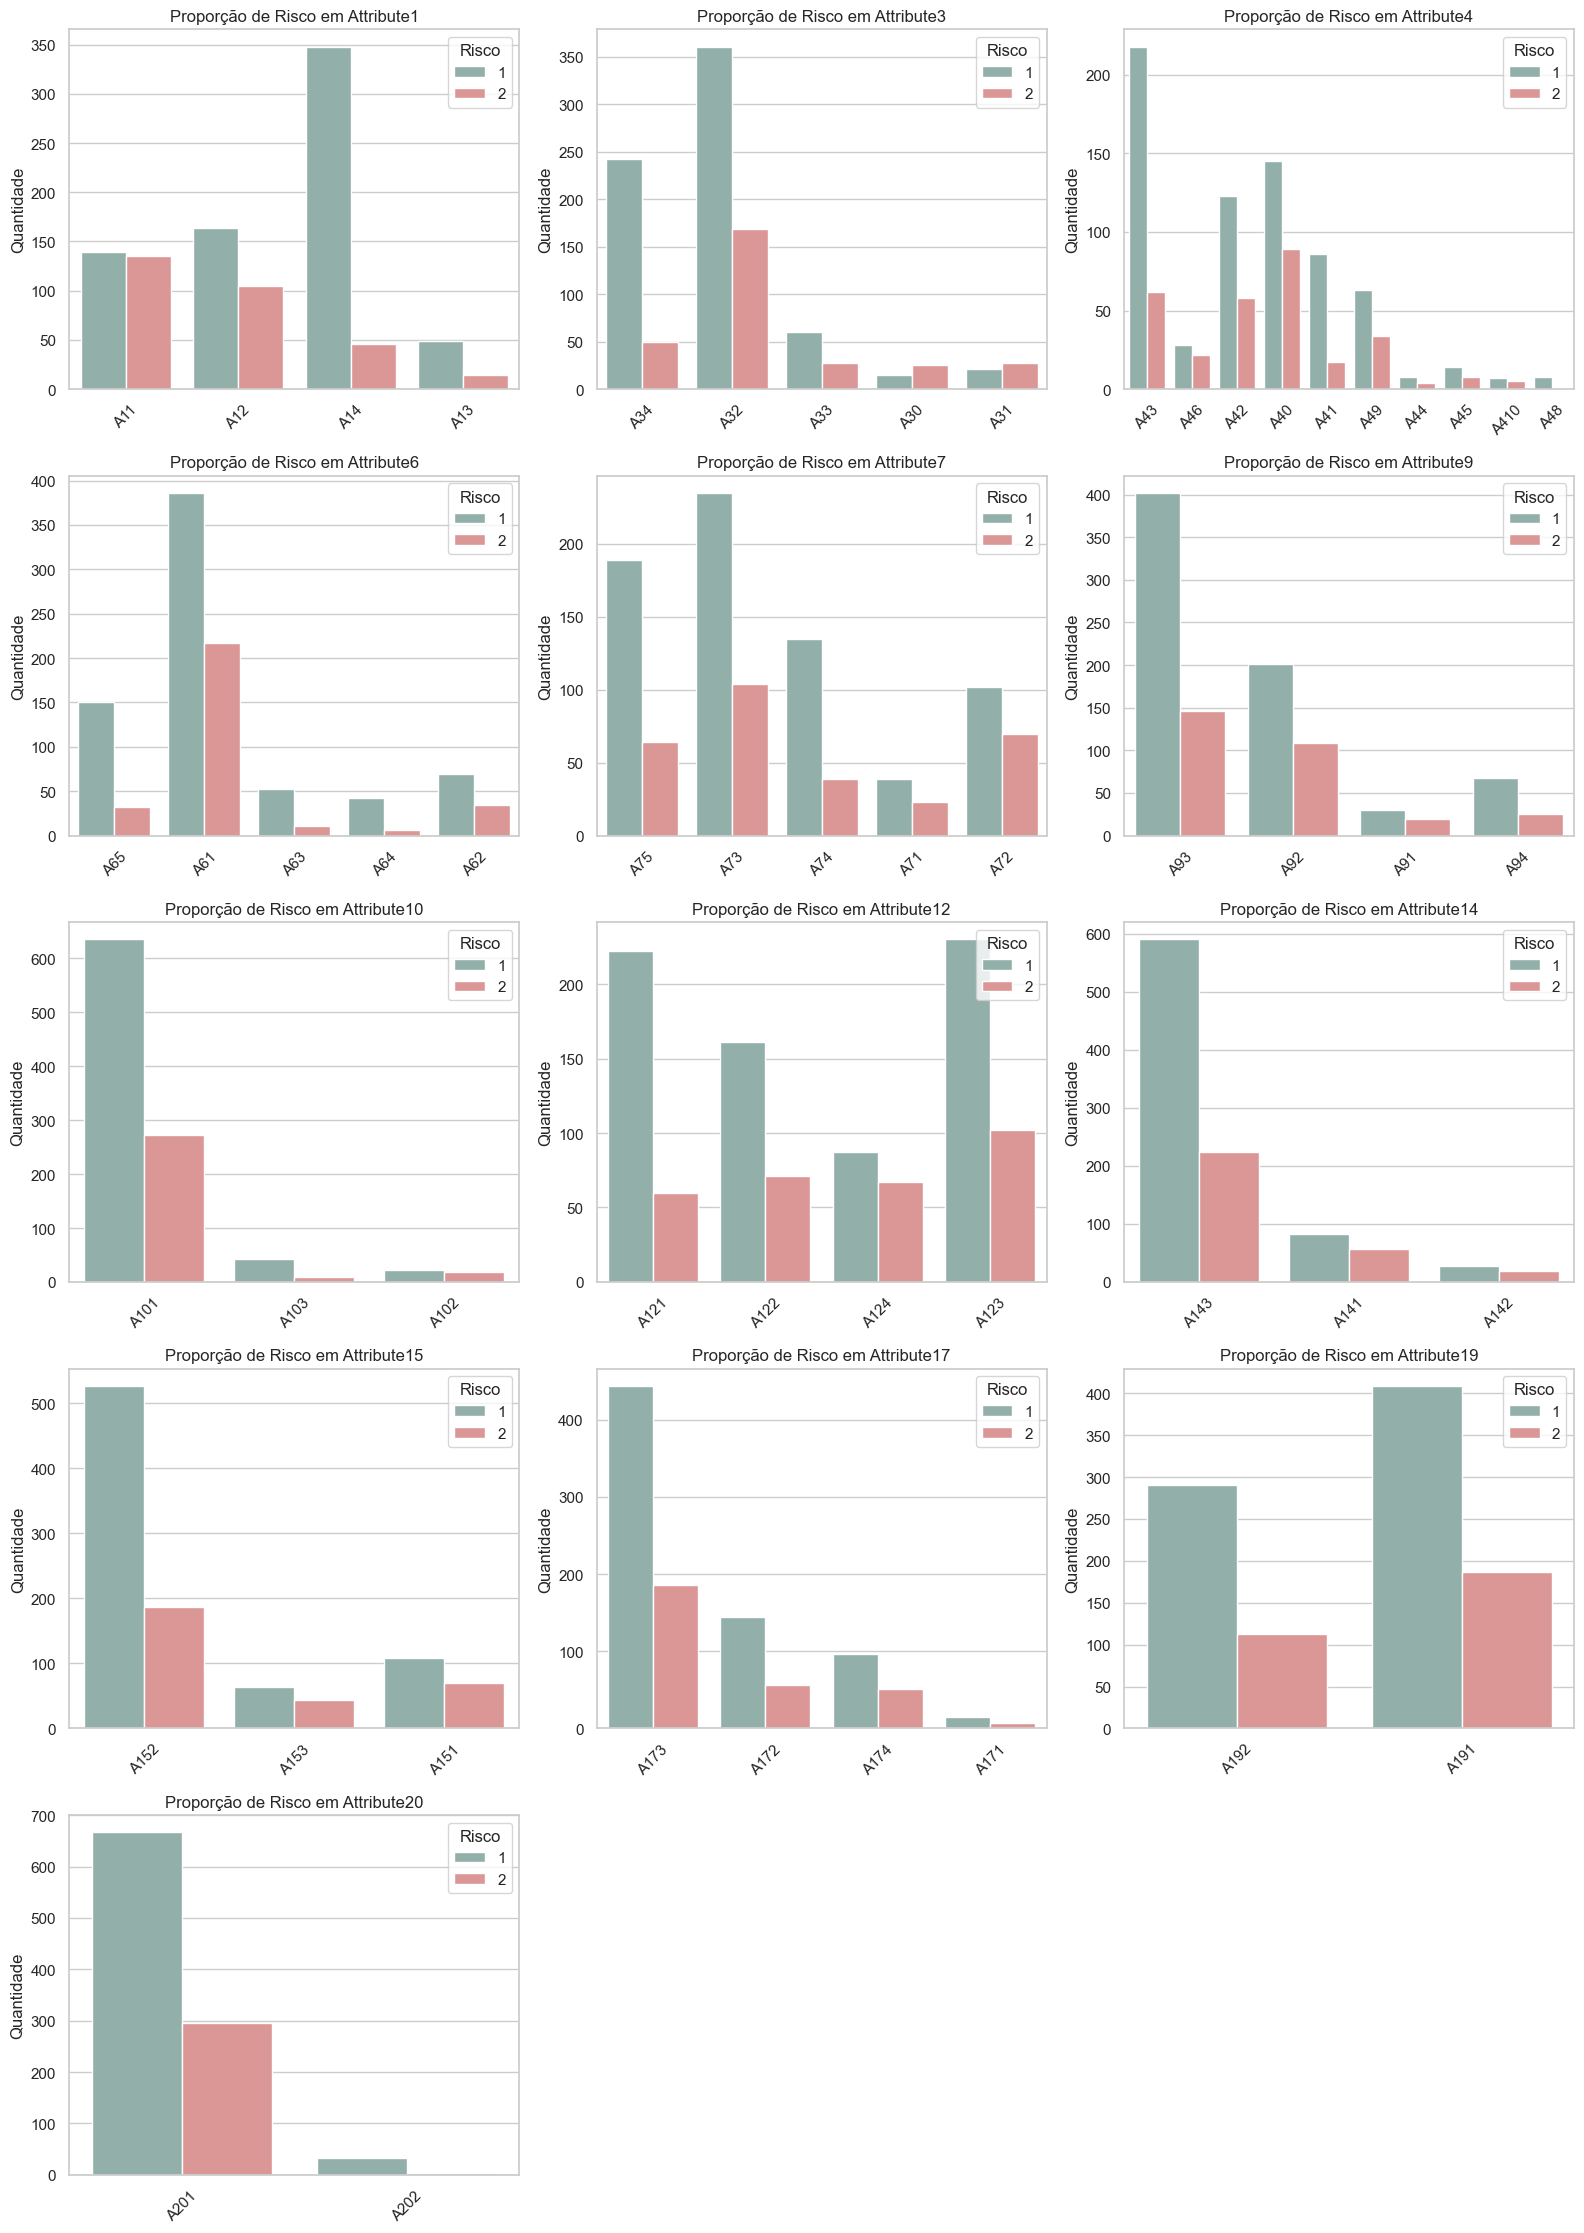

In [ ]:
cores_alvo = ['#8DB4AD', '#E68A8A']

print("--- ANÁLISE BIVARIADA: VARIÁVEIS NUMÉRICAS vs ALVO ---")
linhas_num = math.ceil(len(colunas_numericas) / 3)
fig, axes = plt.subplots(linhas_num, 3, figsize=(15, 4 * linhas_num))
axes = axes.flatten()

for i, col in enumerate(colunas_numericas):
    sns.boxplot(x='class_label', y=col, data=df_eda, ax=axes[i], palette=cores_alvo, hue='class_label', legend=False)
    axes[i].set_title(f'Distribuição de {col}', fontsize=12)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])
    
plt.tight_layout()
plt.show()

print("\n--- ANÁLISE BIVARIADA: VARIÁVEIS CATEGÓRICAS vs ALVO ---")
colunas_categoricas = [col for col in df_eda.columns if col not in colunas_numericas and col not in ['class', 'class_label']]

linhas_cat = math.ceil(len(colunas_categoricas) / 3)
fig, axes = plt.subplots(linhas_cat, 3, figsize=(16, 4.5 * linhas_cat))
axes = axes.flatten()

for i, col in enumerate(colunas_categoricas):
    sns.countplot(x=col, hue='class_label', data=df_eda, ax=axes[i], palette=cores_alvo)
    axes[i].set_title(f'Proporção de Risco em {col}', fontsize=12)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Quantidade')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].legend(title='Risco', loc='upper right')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])
    
plt.tight_layout()
plt.show()



## Pré-processamento de Dados (Pipelines e Transformações)

Com os conjuntos de dados devidamente isolados, blindamos o projeto contra o *Data Leakage* (vazamento de dados). O modelo aprenderá as métricas de padronização exclusivamente no conjunto de **Treino** e apenas aplicará essas regras matemáticas nos conjuntos de **Validação** e **Teste**.

Para orquestrar essa etapa de forma automatizada e escalável, utilizaremos um `ColumnTransformer` do Scikit-Learn com as seguintes etapas:
- **StandardScaler**: Aplicado às variáveis numéricas para nivelar a escala (Média = 0, Desvio Padrão = 1), evitando que variáveis com grandezas maiores (como o valor do crédito) dominem o aprendizado do algoritmo.
- **OneHotEncoder**: Aplicado às variáveis categóricas, convertendo os atributos qualitativos em vetores binários (0 e 1) de forma que o modelo não assuma nenhuma ordem hierárquica inexistente entre as categorias.


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
import pandas as pd

print("--- INICIANDO PRÉ-PROCESSAMENTO ---")

colunas_categoricas = [col for col in X_train.columns if col not in colunas_numericas]

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), colunas_numericas),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), colunas_categoricas)
    ])

X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

nomes_features = preprocessor.get_feature_names_out()
X_train_processed_df = pd.DataFrame(X_train_processed, columns=nomes_features)

print(f"Shape original de Treino: {X_train.shape}")
print(f"Shape após o processamento: {X_train_processed_df.shape}")


--- INICIANDO PRÉ-PROCESSAMENTO ---
Shape original de Treino: (600, 20)
Shape após o processamento: (600, 61)


## Modelagem Preditiva e Matriz de Custos de Negócios

Nesta etapa, construiremos os modelos de classificação e aplicaremos a matriz de custos assimétrica definida pelo problema de negócio do *German Credit*. Como aprovar um crédito para um mau pagador é 5x mais custoso do que recusar um bom cliente, o limiar de decisão (*threshold*) padrão de 0.5 será ajustado para minimizar o prejuízo financeiro total.


In [ ]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix

print("--- TREINAMENTO DO MODELO BASELINE (REGRESSÃO LOGÍSTICA) ---")

# Treinando a Regressão Logística com os dados processados
modelo_baseline = LogisticRegression(random_state=42, max_iter=1000)
modelo_baseline.fit(X_train_processed, y_train['class'])

# Obtendo as probabilidades preditas para o conjunto de validação
# y_val mapeado para binário se necessário (1 = Bom, 2 = Risco)
y_val_bin = y_val['class'].to_numpy()

# Probabilidade da classe de risco (classe 2)
y_val_prob = modelo_baseline.predict_proba(X_val_processed)[:, 1]


def calcular_custo_total(y_true, y_pred):
    r"""
    Calcula o custo financeiro total baseado na matriz de custos:
    Matriz:
      Real vs Pred | Bom (1) | Risco (2)
      ---------------------------------
      Bom (1)      |    0    |    1
      Risco (2)    |    5    |    0
    """
    cm = confusion_matrix(y_true, y_pred, labels=[1, 2])
    fn_como_bom = cm[1, 0]
    fp_como_risco = cm[0, 1]

    custo_total = (fp_como_risco * 1) + (fn_como_bom * 5)
    return custo_total

# Buscando o melhor threshold
limiares = np.linspace(0.1, 0.9, 81)
melhor_limiar = 0.5
menor_custo = float('inf')

for limiar in limiares:
    y_pred_th = np.where(y_val_prob >= limiar, 2, 1)
    custo = calcular_custo_total(y_val_bin, y_pred_th)

    if custo < menor_custo:
        menor_custo = custo
        melhor_limiar = limiar

print(f"Limiar (Threshold) padrão (0.5) - Custo na Validação: {calcular_custo_total(y_val_bin, np.where(y_val_prob >= 0.5, 2, 1))}")
print(f"Melhor Limiar Otimizado por Custos: {melhor_limiar:.2f} - Menor Custo Total: {menor_custo}")


--- TREINAMENTO DO MODELO BASELINE (REGRESSÃO LOGÍSTICA) ---
Limiar (Threshold) padrão (0.5) - Custo na Validação: 197
Melhor Limiar Otimizado por Custos: 0.11 - Menor Custo Total: 100


In [ ]:
# Aplicando o modelo final no conjunto de Teste com o limiar otimizado
y_test_bin = y_test.values
y_test_prob = modelo_baseline.predict_proba(X_test_processed)[:, 1]

# Predição usando o limiar otimizado (0.15) encontrado no conjunto de validação
y_test_pred_otimizado = np.where(y_test_prob >= melhor_limiar, 2, 1)

# Comparação de custos no conjunto de teste
custo_teste_padrao = calcular_custo_total(y_test_bin, modelo_baseline.predict(X_test_processed))
custo_teste_otimizado = calcular_custo_total(y_test_bin, y_test_pred_otimizado)

print("--- AVALIAÇÃO FINAL NO CONJUNTO DE TESTE ---")
print(f"Custo no Teste com Limiar Padrão (0.5): {custo_teste_padrao}")
print(f"Custo no Teste com Limiar Otimizado ({melhor_limiar:.2f}): {custo_teste_otimizado}")


--- AVALIAÇÃO FINAL NO CONJUNTO DE TESTE ---
Custo no Teste com Limiar Padrão (0.5): 154
Custo no Teste com Limiar Otimizado (0.11): 122


## Comparacao de Modelos Sensiveis ao Custo

Nesta etapa, comparamos Regressao Logistica, Random Forest e Gradient Boosting usando a mesma regra de negocio: escolher no conjunto de validacao o limiar que minimiza a matriz de custos e aplicar esse limiar no conjunto de teste.


In [ ]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

modelos = {
    'Regressao Logistica': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=300),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42)
}

resultados_modelos = []

def obter_probabilidade_risco(modelo, X_processado):
    indice_risco = list(modelo.classes_).index(2)
    return modelo.predict_proba(X_processado)[:, indice_risco]

for nome_modelo, modelo in modelos.items():
    modelo.fit(X_train_processed, y_train['class'])

    y_val_prob_modelo = obter_probabilidade_risco(modelo, X_val_processed)

    melhor_limiar_modelo = 0.5
    menor_custo_modelo = float('inf')

    for limiar in limiares:
        y_val_pred_modelo = np.where(y_val_prob_modelo >= limiar, 2, 1)
        custo_validacao = calcular_custo_total(y_val_bin, y_val_pred_modelo)

        if custo_validacao < menor_custo_modelo:
            menor_custo_modelo = custo_validacao
            melhor_limiar_modelo = limiar

    y_test_prob_modelo = obter_probabilidade_risco(modelo, X_test_processed)
    y_test_pred_modelo = np.where(y_test_prob_modelo >= melhor_limiar_modelo, 2, 1)
    custo_teste_modelo = calcular_custo_total(y_test_bin, y_test_pred_modelo)

    cm_teste = confusion_matrix(y_test_bin, y_test_pred_modelo, labels=[1, 2])

    resultados_modelos.append({
        'Modelo': nome_modelo,
        'Melhor threshold': round(melhor_limiar_modelo, 2),
        'Custo validacao': menor_custo_modelo,
        'Custo teste': custo_teste_modelo,
        'Bons classificados como risco': cm_teste[0, 1],
        'Riscos classificados como bons': cm_teste[1, 0]
    })

resultados_modelos_df = pd.DataFrame(resultados_modelos).sort_values('Custo teste')
resultados_modelos_df


## Taxa de Risco por Categoria

Os graficos anteriores mostram contagens absolutas. Para evitar confundir volume com risco, esta etapa calcula a taxa percentual de bons e maus pagadores dentro de cada categoria.


In [ ]:
for col in colunas_categoricas:
    taxa_risco = (
        pd.crosstab(df_eda[col], df_eda['class_label'], normalize='index') * 100
    )

    taxa_risco = taxa_risco.rename(columns={1: 'Bom (%)', 2: 'Risco (%)'})
    taxa_risco = taxa_risco.sort_values('Risco (%)', ascending=False)

    print(f"\n--- Categorias com maior taxa de risco: {col} ---")
    print(taxa_risco[['Risco (%)']].head(5).round(2))



--- Categorias com maior taxa de risco: Attribute1 ---
class_label  Risco (%)
Attribute1            
A11              49.27
A12              39.03
A13              22.22
A14              11.68

--- Categorias com maior taxa de risco: Attribute3 ---
class_label  Risco (%)
Attribute3            
A30              62.50
A31              57.14
A32              31.89
A33              31.82
A34              17.06

--- Categorias com maior taxa de risco: Attribute4 ---
class_label  Risco (%)
Attribute4            
A46              44.00
A410             41.67
A40              38.03
A45              36.36
A49              35.05

--- Categorias com maior taxa de risco: Attribute6 ---
class_label  Risco (%)
Attribute6            
A61              35.99
A62              33.01
A65              17.49
A63              17.46
A64              12.50

--- Categorias com maior taxa de risco: Attribute7 ---
class_label  Risco (%)
Attribute7            
A72              40.70
A71              37.10
A73    

## Comparação de Modelos Sensíveis ao Custo

Nesta etapa, comparamos Regressão Logística, Random Forest e Gradient Boosting usando a mesma regra de negócio: escolher no conjunto de validação o limiar que minimiza a matriz de custos e aplicar esse limiar no conjunto de teste.

In [ ]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

modelos = {
    'Regressão Logística': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=300),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42)
}

resultados_modelos = []

def obter_probabilidade_risco(modelo, X_processado):
    indice_risco = list(modelo.classes_).index(2)
    return modelo.predict_proba(X_processado)[:, indice_risco]

for nome_modelo, modelo in modelos.items():
    modelo.fit(X_train_processed, y_train['class'])

    y_val_prob_modelo = obter_probabilidade_risco(modelo, X_val_processed)

    melhor_limiar_modelo = 0.5
    menor_custo_modelo = float('inf')

    for limiar in limiares:
        y_val_pred_modelo = np.where(y_val_prob_modelo >= limiar, 2, 1)
        custo_validacao = calcular_custo_total(y_val_bin, y_val_pred_modelo)

        if custo_validacao < menor_custo_modelo:
            menor_custo_modelo = custo_validacao
            melhor_limiar_modelo = limiar

    y_test_prob_modelo = obter_probabilidade_risco(modelo, X_test_processed)
    y_test_pred_modelo = np.where(y_test_prob_modelo >= melhor_limiar_modelo, 2, 1)
    custo_teste_modelo = calcular_custo_total(y_test_bin, y_test_pred_modelo)

    cm_teste = confusion_matrix(y_test_bin, y_test_pred_modelo, labels=[1, 2])

    resultados_modelos.append({
        'Modelo': nome_modelo,
        'Melhor threshold': round(melhor_limiar_modelo, 2),
        'Custo validação': menor_custo_modelo,
        'Custo teste': custo_teste_modelo,
        'Bons classificados como risco': cm_teste[0, 1],
        'Riscos classificados como bons': cm_teste[1, 0]
    })

resultados_modelos_df = pd.DataFrame(resultados_modelos).sort_values('Custo teste')
resultados_modelos_df